In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep  

In [2]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/NonResonant_final_merged.root"
bg_path     = "/home/tandrade/Flavour_Anomalies/Data/Data_final_merged.root"
tree_name   = "tree_ML"

In [3]:
features = [
    'BToTrkTrkMuMu_l_xy_good',
    'BToTrkTrkMuMu_l_xy_unc_good',
    
    'BToTrkTrkMuMu_dca_good',
    'BToTrkTrkMuMu_dcaErr_good',

    'BToTrkTrkMuMu_trk1_dca_good',
    'BToTrkTrkMuMu_trk1_dcaErr_good',
    
    'BToTrkTrkMuMu_trk2_dca_good',
    'BToTrkTrkMuMu_trk2_dcaErr_good',
    
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good',
    'BToTrkTrkMuMu_svprob_good'
]

cut_features = [
    'MuMu_mass_good', 
    'BToTrkTrkMuMu_fit_mass_Kpi_good',
    'HLT_DoubleMu4_3_LowMass'
]


features_plot = [
    'BToTrkTrkMuMu_l_xy_sig_good',    # Substituiu l_xy e unc
    'BToTrkTrkMuMu_dca_sig_good',     # Substituiu dca e dcaErr
    'BToTrkTrkMuMu_trk1_dca_sig_good',# Substituiu trk1 dca e dcaErr
    'BToTrkTrkMuMu_trk2_dca_sig_good',# Substituiu trk2 dca e dcaErr
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good',
    'BToTrkTrkMuMu_svprob_good'
]

In [4]:
signal_file = uproot.open(signal_path)[tree_name]
background_file = uproot.open(bg_path)[tree_name]

In [5]:
for branche in signal_file.keys():
    if "HLT" in branche:
        print(branche)

HLT_DoubleMu4_Jpsi_NoVertexing
HLT_DoubleMu4_Mass3p8_DZ_PFHT350
HLT_DoubleMu4_JpsiTrkTrk_Displaced
HLT_DoubleMu4_3_Bs
HLT_DoubleMu4_JpsiTrk_Bc
HLT_DoubleMu4_LowMass_Displaced
HLT_DoubleMu4_MuMuTrk_Displaced
HLT_DoubleMu4_3_Displaced_Photon4_BsToMMG
HLT_DoubleMu4_Jpsi_Displaced
HLT_DoubleMu4_3_Jpsi
HLT_DoubleMu4_3_Photon4_BsToMMG
HLT_DoubleMu4_3_LowMass


In [6]:
cols_to_load = features + cut_features

signal_ak = signal_file.arrays(cols_to_load, library="ak")
background_ak = background_file.arrays(cols_to_load, library="ak")

In [7]:
signal_df = ak.to_dataframe(signal_ak)
background_df = ak.to_dataframe(background_ak)

In [8]:
sig_pairs = [
    ('BToTrkTrkMuMu_l_xy_good', 'BToTrkTrkMuMu_l_xy_unc_good', 'BToTrkTrkMuMu_l_xy_sig_good'),
    ('BToTrkTrkMuMu_dca_good', 'BToTrkTrkMuMu_dcaErr_good', 'BToTrkTrkMuMu_dca_sig_good'),
    ('BToTrkTrkMuMu_trk1_dca_good', 'BToTrkTrkMuMu_trk1_dcaErr_good', 'BToTrkTrkMuMu_trk1_dca_sig_good'),
    ('BToTrkTrkMuMu_trk2_dca_good', 'BToTrkTrkMuMu_trk2_dcaErr_good', 'BToTrkTrkMuMu_trk2_dca_sig_good')
]

for val, err, sig in sig_pairs:
    signal_df[sig] = signal_df[val] / signal_df[err]

for val, err, sig in sig_pairs:
    background_df[sig] = background_df[val] / background_df[err]

In [9]:
signal_df["label"] = 1
background_df["label"] = 0

In [10]:
df = pd.concat([signal_df, background_df], ignore_index=True)

In [11]:
cut_mass_B = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
cut_mass_MuMu = ( ((df['MuMu_mass_good'] > 1.0) & (df['MuMu_mass_good'] < 2.9)) | ((df['MuMu_mass_good'] > 4.0) & (df['MuMu_mass_good'] < 4.8)) )
cut_trigger = df['HLT_DoubleMu4_3_LowMass'] == 1
final_cut = cut_mass_B & cut_mass_MuMu & cut_trigger
df_cut = df[final_cut] 

In [12]:
final_cols = features + features_plot + ['label'] 
df_final = df_cut[final_cols].copy()
df = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

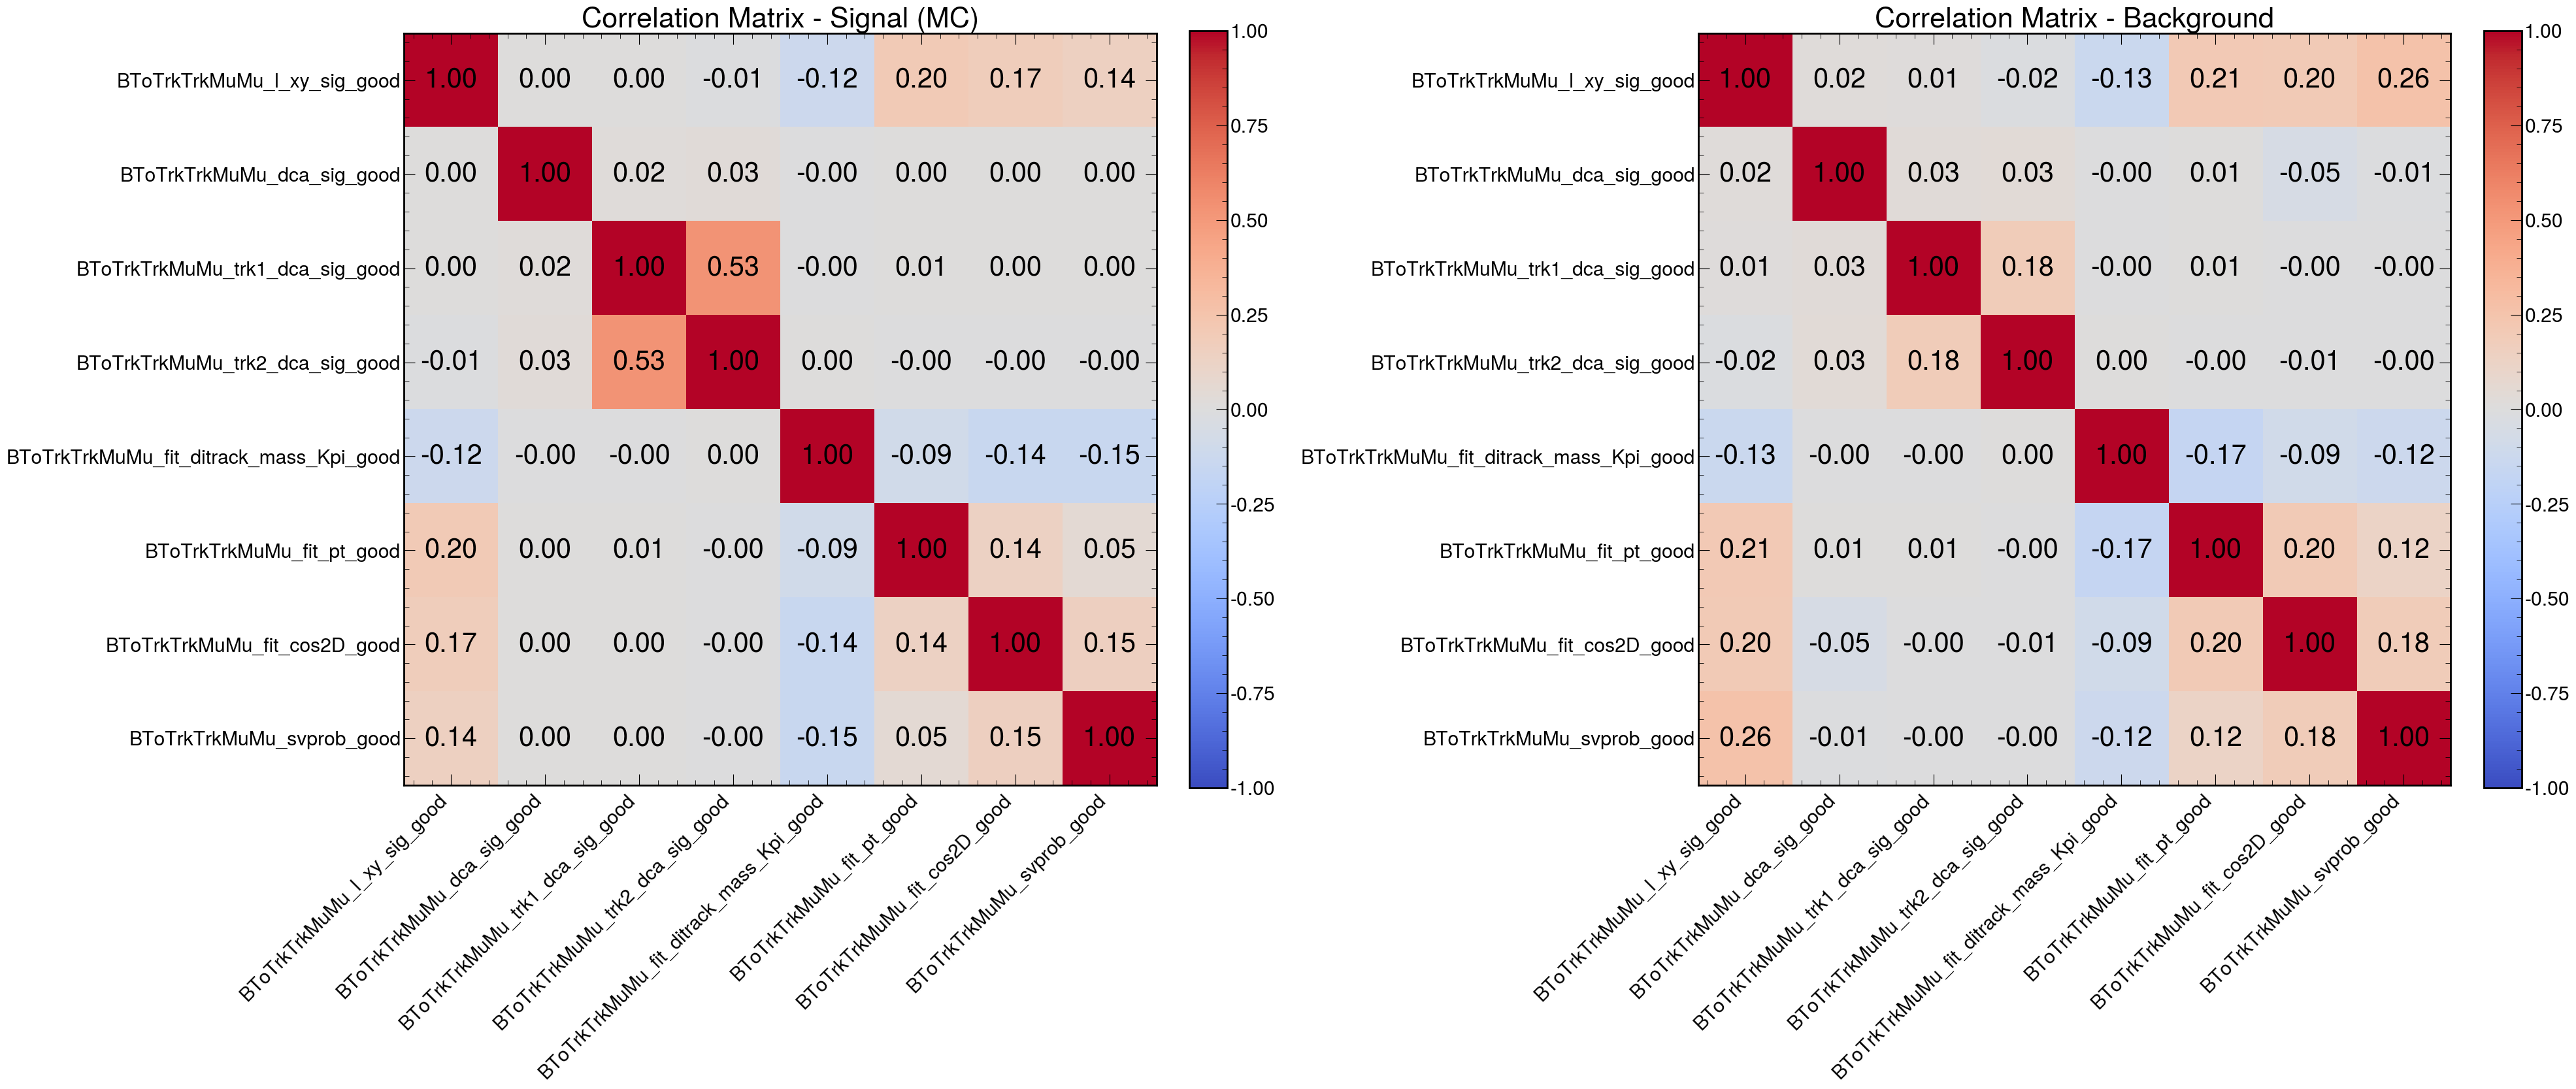

In [13]:
plt.style.use(hep.style.CMS)
plt.figure(figsize=(40, 25))

# --- Matriz Signal ---
ax1 = plt.subplot(1,2,1)
corr_signal = signal_df[features_plot].corr()
im1 = plt.imshow(corr_signal, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im1, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix - Signal (MC)")

# Ajuste nos ticks: usar features_plot
plt.xticks(ticks=np.arange(len(features_plot)), labels=features_plot, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features_plot)), labels=features_plot)

for i in range(len(features_plot)):
    for j in range(len(features_plot)):
        plt.text(j, i, f"{corr_signal.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=30)

# --- Matriz Background ---
ax2 = plt.subplot(1,2,2)
corr_background = background_df[features_plot].corr()
im2 = plt.imshow(corr_background, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix - Background")

# Ajuste nos ticks: usar features_plot
plt.xticks(ticks=np.arange(len(features_plot)), labels=features_plot, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features_plot)), labels=features_plot)

for i in range(len(features_plot)):
    for j in range(len(features_plot)):
        plt.text(j, i, f"{corr_background.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=30)

plt.tight_layout()
plt.savefig("Plots/correlation_matrices.png", dpi=100, bbox_inches='tight')
plt.show()

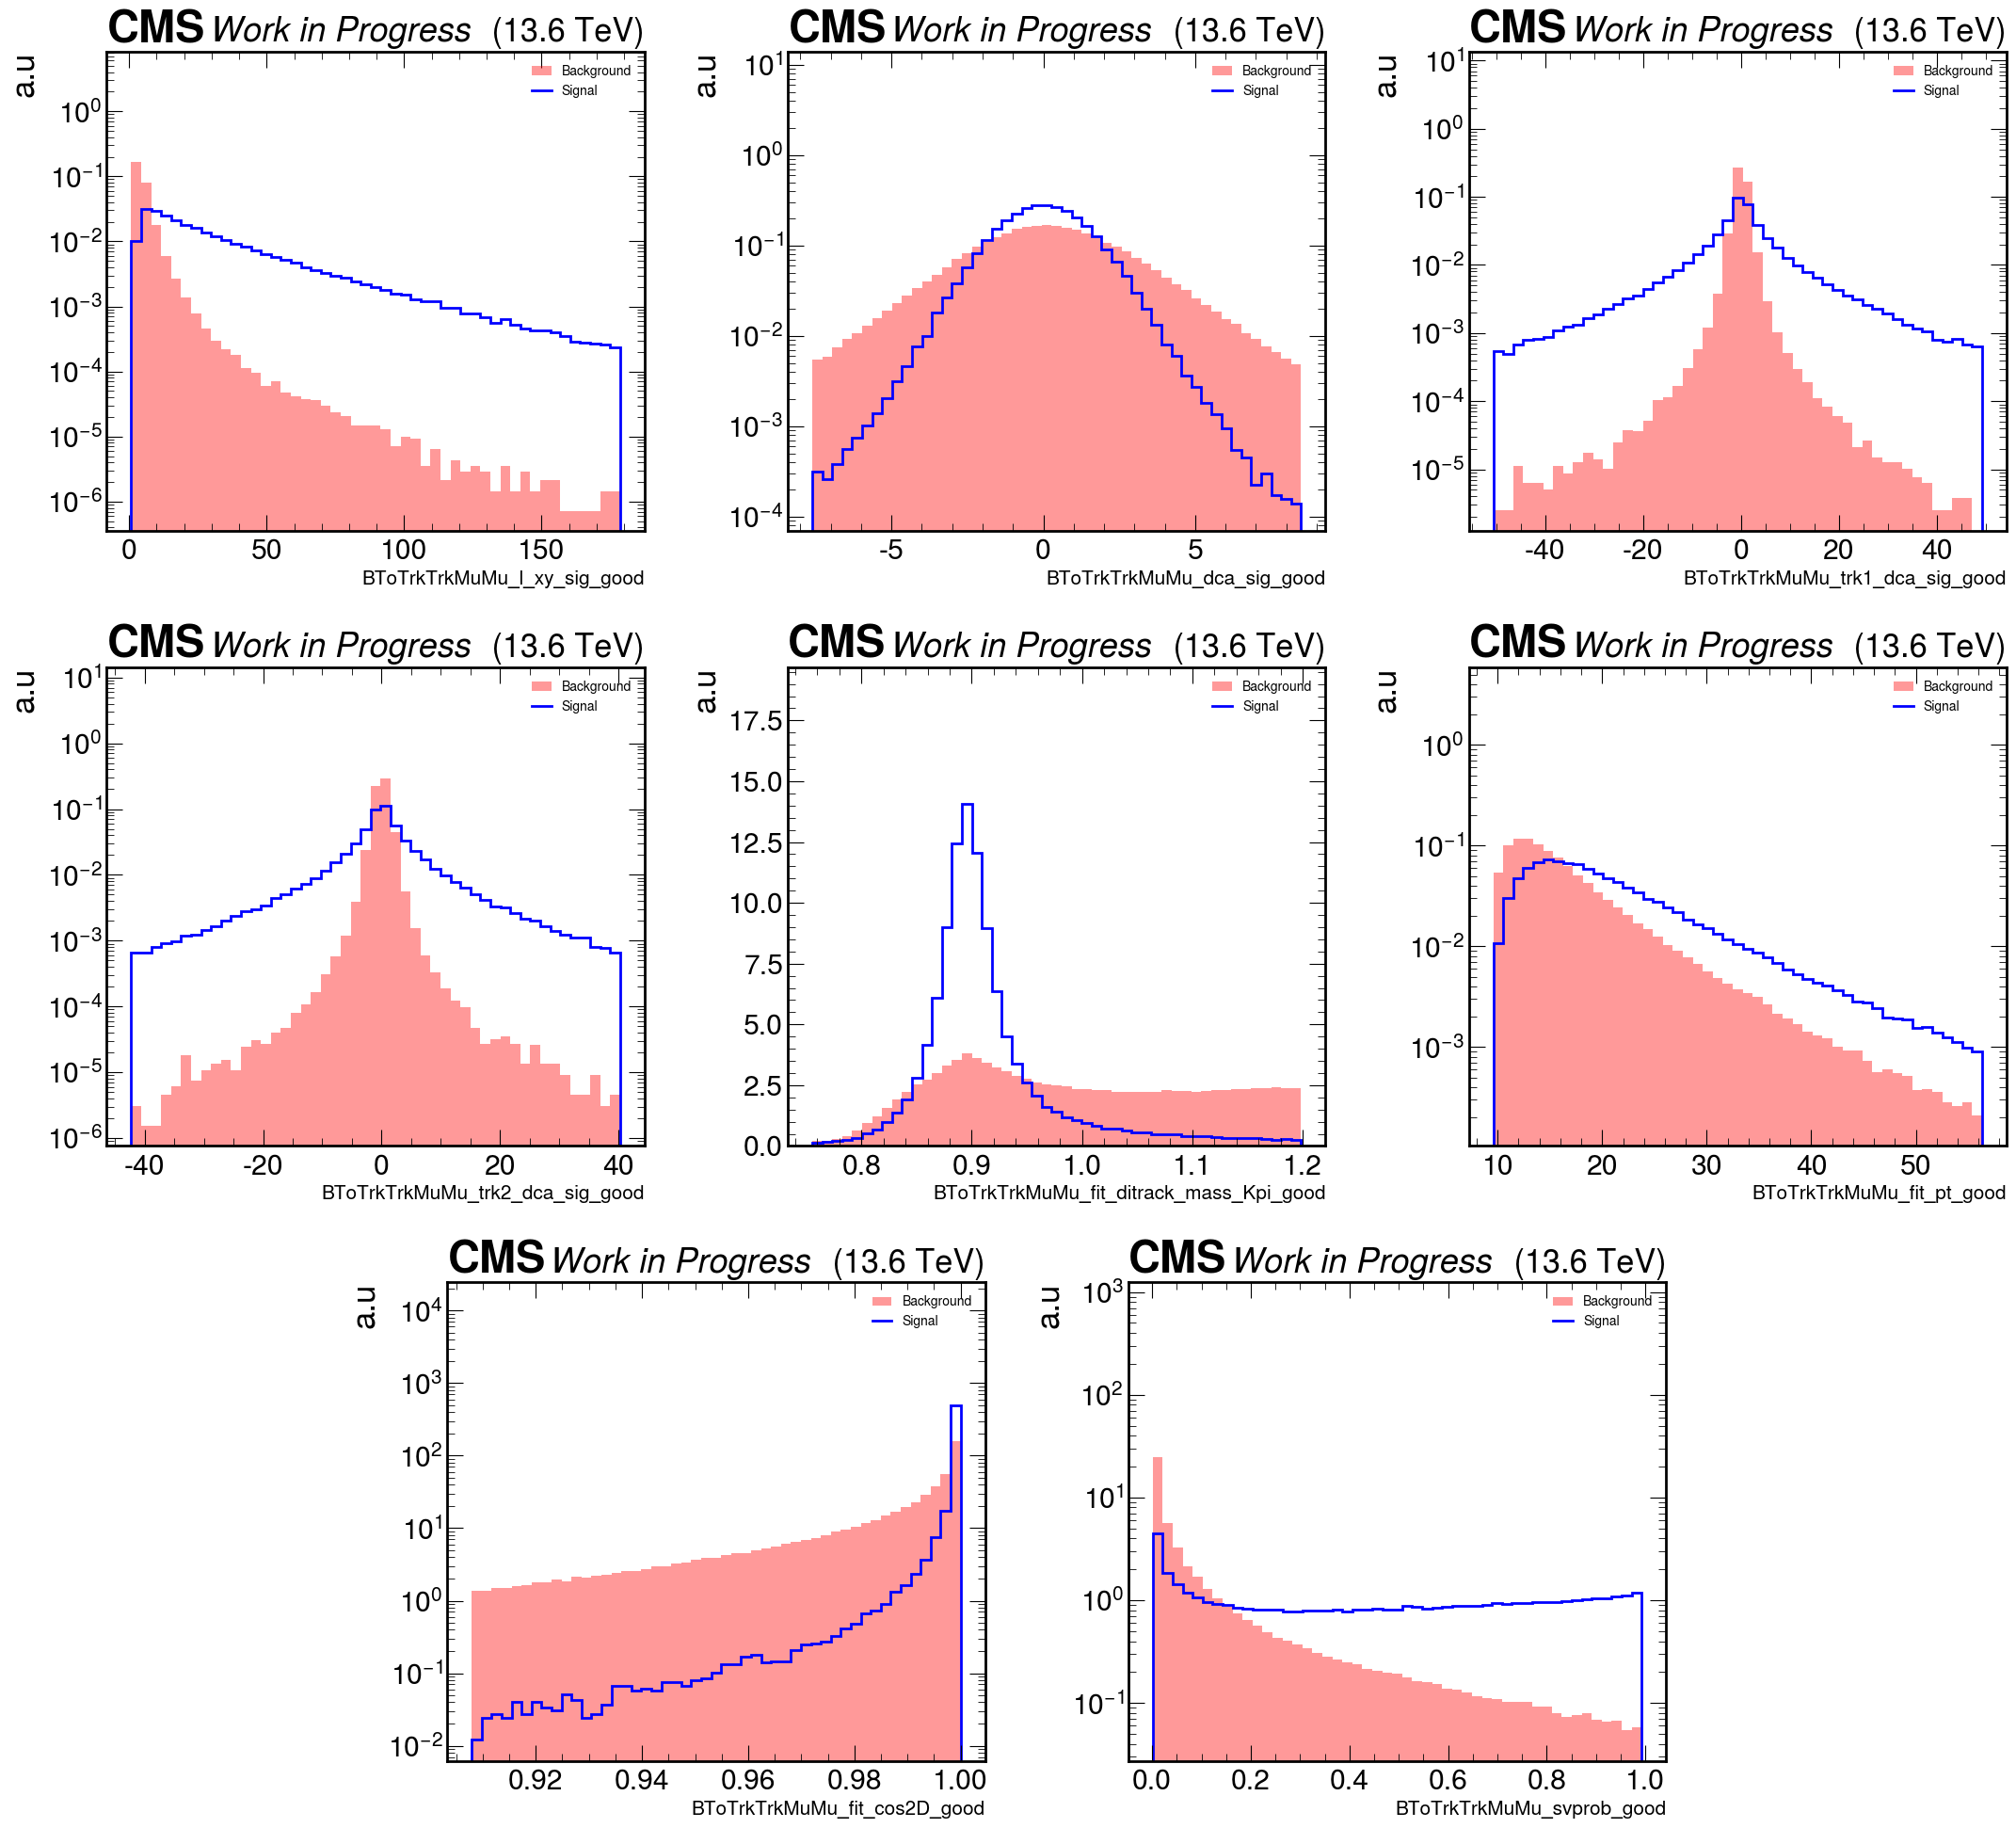

In [14]:
plt.style.use(hep.style.ROOT)

def plot_custom_grid(df, features, log_features=[]):

    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(3, 6)
    
    axes = []
    axes.append(fig.add_subplot(gs[0, 0:2])) # Colunas 0 e 1
    axes.append(fig.add_subplot(gs[0, 2:4])) # Colunas 2 e 3
    axes.append(fig.add_subplot(gs[0, 4:6])) # Colunas 4 e 5
    
    axes.append(fig.add_subplot(gs[1, 0:2]))
    axes.append(fig.add_subplot(gs[1, 2:4]))
    axes.append(fig.add_subplot(gs[1, 4:6]))
    
    axes.append(fig.add_subplot(gs[2, 1:3])) 
    axes.append(fig.add_subplot(gs[2, 3:5])) 
    
    for i, feature in enumerate(features):
        if i >= len(axes): break
        
        ax = axes[i]
        
        sig_data = df[df['label'] == 1][feature].dropna()
        bkg_data = df[df['label'] == 0][feature].dropna()
        
        if len(sig_data) == 0 or len(bkg_data) == 0: continue

        low = min(np.percentile(sig_data, 1), np.percentile(bkg_data, 1))
        high = max(np.percentile(sig_data, 99), np.percentile(bkg_data, 99))
        bins = np.linspace(low, high, 50)
        
        counts_bkg, _ = np.histogram(bkg_data, bins=bins, density=True)
        counts_sig, _ = np.histogram(sig_data, bins=bins, density=True)
        
        hep.histplot(counts_bkg, bins=bins, ax=ax, label='Background', color='red', alpha=0.4, histtype='fill')        
        hep.histplot(counts_sig, bins=bins, ax=ax, label='Signal', color='blue', linewidth=2, histtype='step')
        
        if feature in log_features:
            ax.set_yscale('log')
            all_counts = np.concatenate([counts_bkg, counts_sig])
            min_val = np.min(all_counts[all_counts > 0])
            ax.set_ylim(bottom=min_val * 0.5, top=np.max(all_counts) * 50)
            ylabel_text = "a.u"
        else:
            ylabel_text = "a.u"
            ax.set_ylim(top=np.max(np.concatenate([counts_bkg, counts_sig])) * 1.4)

        ax.set_xlabel(feature, fontsize=15)
        ax.set_ylabel(ylabel_text, fontsize=25)
        ax.legend(loc='best', fontsize=10)
        hep.cms.label(loc=0, ax=ax, data=True, com="13.6", label="Work in Progress")

    plt.tight_layout()
    plt.savefig("Plots/Overlay.png")
    plt.show()


features_para_log = [
    "BToTrkTrkMuMu_l_xy_sig_good",
    "BToTrkTrkMuMu_dca_sig_good",
    "BToTrkTrkMuMu_trk1_dca_sig_good",
    "BToTrkTrkMuMu_trk2_dca_sig_good",
    "BToTrkTrkMuMu_fit_pt_good",
    "BToTrkTrkMuMu_fit_cos2D_good",
    "BToTrkTrkMuMu_svprob_good"
]

plot_custom_grid(df, features_plot, log_features=features_para_log)